# Revenue-Surprise-Drift — a quantitative teardown 🔬
### SUR quintile long-short · forward 1/5/20/60-day drift · one-sample *t* + label-shuffle & block placebo nulls · costs × turnover · the within-EPS-strata incremental test · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds_info_beyond_EPS%3F: Busted](https://img.shields.io/badge/Adds_info_beyond_EPS%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is **Jegadeesh & Livnat (2006)**: the post-earnings drift follows the **revenue** surprise *incremental to* the earnings surprise. The job here is to measure it honestly on a tradable basket — form the **standardized unexpected revenue (SUR)**, sort, confront it with a clustering-aware placebo, charge it real costs, and run the decisive **within-EPS-strata** test of the incremental claim.

> ⚠️ **Data + survivorship note.** Fixed **30-name large-cap** basket, names still trading in 2026 — a *survivor* panel that tilts the long leg up and sits at the **conservative** end of the drift's range (the effect is strongest in small illiquid names; Chordia et al. 2009). Real data: yfinance daily closes + **EDGAR** frame-tagged quarterly revenue, 2013→2026 (**592 events** — thinner than the EPS study). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from revenue_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EV = data.load_real()      # event table carries the SUR
else:
    PRICES = EV = None
print("real revenue cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2013-02-11', 'end': '2026-06-03', 'years': 13.3, 'n_events': 592, 'n_names': 29, 'h1': (1, 592, 0.15, 0.02, 0.13, 51, 0.59, 0.281), 'h5': (5, 592, 0.47, 0.82, -0.35, 51, -0.7, 0.751), 'h20': (20, 586, 1.5, 1.04, 0.46, 50, 0.49, 0.32), 'h60': (60, 542, 2.81, 3.96, -1.15, 53, -0.75, 0.732), 'net': [(1, 0.13, -0.27), (5, -0.35, -0.76), (20, 0.46, 0.02), (60, -1.15, -1.67)], 'quintile20': [1.04, 2.8, 1.73, 0.5, 1.5], 'robust': [(3, -0.44, -0.59, 0.717), (5, 0.46, 0.49, 0.32), (10, -0.01, -0.02, 0.501)], 'block_p20': 0.582, 'inc': [('eps+ (beats)', 488, -0.3, -0.35), ('eps- (misses)', 72, -0.67, -0.19)], 'inc_pooled': (560, -0.19, -0.4), 'syn': [(0.0, 1224, 0.02, 0.03, 0.494, 48), (0.08, 1224, 5.38, 9.55, 0.0, 67)]}


real revenue cache present: True | events: 592 | names: 29


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SUR long-short **never clears t = 2**: max **t = 0.59** (1d); 20d **+0.46%** at **t = 0.49**, placebo **p = 0.320**; sign flips across horizons and bucket counts; block placebo **p = 0.582**. |
| **Tradability** | `MIRAGE` | Net of 4×10-bps + borrow, every horizon ≤ **+0.02%** (best, 20d); no gross edge to erode. |
| **Adds info beyond EPS?** | `BUSTED` | SUR sort within EPS-sign strata: pooled **-0.19%** at **t = -0.40** (negative in both beats and misses). The Jegadeesh-Livnat incremental claim does not replicate. |

> 💡 In plain words: on this basket the **earnings** surprise drifts (study 363, t = 2.96) but the **revenue** surprise does not — and it carries no information the earnings surprise didn't already. A clean None × Mirage; the synthetic control confirms the detector is faithful, so this is a real absence of signal.

## 1 · The claim, steelmanned

Let $\mathrm{SUR}_i$ be the standardized unexpected revenue for event $i$ — the seasonal random-walk surprise scaled by its own trailing volatility,

$$\mathrm{SUR}_q = \frac{\mathrm{Rev}_q - \mathrm{Rev}_{q-4}}{\widehat{\sigma}\big(\{\mathrm{Rev}_s - \mathrm{Rev}_{s-4}\}_{s<q}\big)},$$

the revenue analogue of academic SUE. Let $r_i(H)$ be the forward $H$-day return entered **one day after** the 10-Q/10-K filing is public (no look-ahead). Quintile by SUR; the long-short is $\widehat{\Lambda}(H) = \overline{r}_{Q_5}(H) - \overline{r}_{Q_1}(H)$.

- **H₁ (the drift exists).** $\widehat{\Lambda}(H) > 0$ and significant for some $H$.
- **H₂ (deployable).** survives one-way costs × per-event turnover + short borrow.
- **H₃ (incremental, the Jegadeesh-Livnat claim).** the SUR long-short survives *within* EPS-sign strata — i.e. revenue adds information beyond the EPS surprise.

We find **H₁ rejected** (max t = 0.59), **H₂ rejected** (net ≤ +0.02%), **H₃ rejected** (within-EPS pooled t = −0.40). None of the three survives on this universe.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of the pooled long-short sample (top-quintile drifts as longs, bottom-quintile drifts as $-$shorts) against zero:

$$t = \frac{\overline{\lambda}}{s_\lambda/\sqrt{k}},\qquad \lambda \in \{r_i : i\in Q_5\}\cup\{-r_i : i\in Q_1\}.$$

Two honesty problems sit on top of a naive *t*. **(a) Clustering:** filings arrive in **seasons**, so events aren't independent and a raw *t* overstates significance — we add a **within-quarter block placebo** that shuffles SUR labels *inside* each calendar quarter. **(b) Confounding with EPS:** revenue and earnings surprises are correlated, so a raw SUR drift could just be the EPS drift; the **within-EPS-strata** test isolates the *incremental* revenue signal — the actual Jegadeesh-Livnat claim.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket (yfinance adjusted closes); **592** quarterly revenue events across **29** names with usable history (2013-02-11→2026-06-03). **Survivor** panel — named on Signal.
- **Surprise.** **SUR** = seasonal random-walk revenue surprise scaled by trailing seasonal-diff volatility (≥8 prior seasonal diffs required), from **EDGAR** frame-tagged quarterly revenue.
- **Timing.** Anchor at the first session on/after the **filing date**; enter the close **1 day later** (no look-ahead); hold $H\in\{1,5,20,60\}$ days; drop window-overruns.
- **Signal.** Quintile by SUR; long $Q_5$ − short $Q_1$.
- **Null #1 (one-sample t)** of the pooled long-short sample vs 0.
- **Null #2 (label-shuffle placebo).** 20,000 random re-sorts; $p = \Pr[\text{shuffled }\Lambda \ge \text{observed}]$.
- **Null #3 (block placebo).** shuffle labels *within calendar quarter*.
- **Costs.** 10 bps one-way × 4 legs + 50 bps/yr borrow on the short leg.
- **Incremental test.** SUR long-short within EPS-sign strata (EPS from study 363).
- **Positive control.** deterministic panel with a **planted** drift: zero edge must NOT reach significance; a large edge must light up.

## 4 · The teardown

### 4a · Monotonicity + the term structure of the drift

Left: mean drift by SUR quintile at 20d (the cross-sectional sort — should climb). Right: the long-short at each horizon (the term structure — should be positive and building if the drift is real).

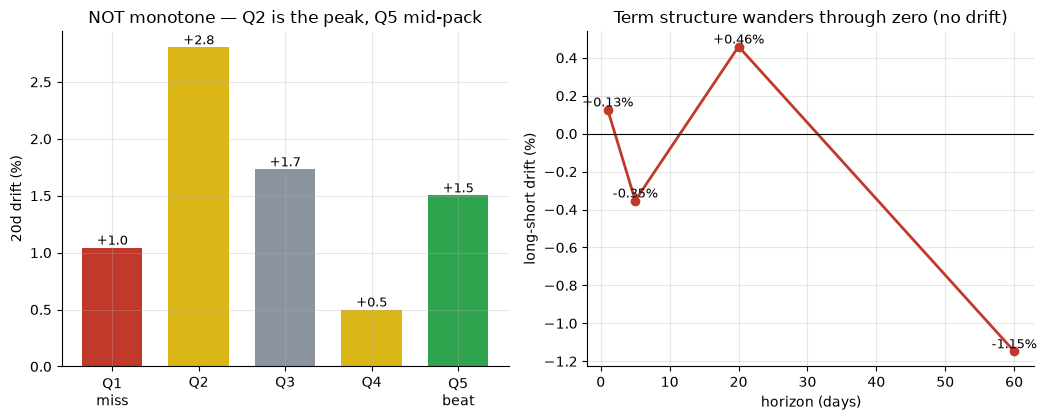

quintile 20d: [1.04, 2.8, 1.73, 0.5, 1.5]
long-short by H: [0.13, -0.35, 0.46, -1.15]


In [2]:
hs = [1, 5, 20, 60]
if HAVE_REAL:
    q20 = st.bucket_means(st.event_drift_frame(PRICES, EV, 20), 'sur')*100
    ls = [st.summarize(PRICES, EV, h, surprise_col='sur', placebo=False)['ls_mean']*100 for h in hs]
else:
    q20 = np.array(R['quintile20']); ls = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(range(5), q20, color=[RED,AMBER,GREY,AMBER,GREEN], width=.7)
a1.set_xticks(range(5)); a1.set_xticklabels(['Q1\nmiss','Q2','Q3','Q4','Q5\nbeat'])
a1.set_ylabel('20d drift (%)'); a1.set_title('NOT monotone — Q2 is the peak, Q5 mid-pack')
for i,v in enumerate(q20): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.plot(hs, ls, 'o-', c=RED, lw=2)
a2.axhline(0, c='k', lw=.8)
for h,v in zip(hs,ls): a2.annotate(f'{v:+.2f}%',(h,v),ha='center',va='bottom',fontsize=9)
a2.set_xlabel('horizon (days)'); a2.set_ylabel('long-short drift (%)')
a2.set_title('Term structure wanders through zero (no drift)')
plt.tight_layout(); plt.show()
print('quintile 20d:', [round(float(v),2) for v in q20]); print('long-short by H:', [round(v,2) for v in ls])

> 💡 In plain words: the cross-section has **no ladder** (Q2 **+2.80%** is the peak; Q5 **+1.50%** is mid-pack), and the term structure crosses zero (**-0.35%** at 5d, **-1.15%** at 60d). Neither shape is what a real drift looks like.

### 4b · The decisive test — significance + a clustering-aware placebo

The 20-day long-short against a 20,000-draw label-shuffle null. A real spread would sit in the far right tail; this one sits **inside the cloud**. We also report the **within-quarter block placebo** that respects filing-season clustering.

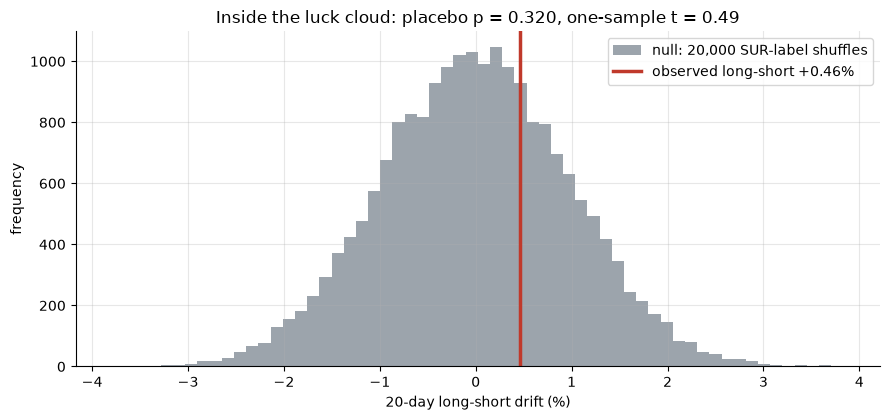

observed +0.46%  one-sample t=0.49  shuffle p=0.320  block p=0.584


In [3]:
if HAVE_REAL:
    fr = st.event_drift_frame(PRICES, EV, 20)
    pl = st.placebo_pvalue(fr, 'sur', n_draws=20000)
    obs = pl['obs']*100; draws = pl['draws']*100; pval = pl['p_value']
    tval = st.summarize(PRICES, EV, 20, surprise_col='sur', placebo=False)['t']
    blk = st.block_placebo_pvalue(fr, 'sur', n_draws=4000)
else:
    obs = R['h20'][4]; pval = R['h20'][7]; tval = R['h20'][6]; blk = R['block_p20']
    rng = np.random.default_rng(534); draws = rng.normal(0.0, 0.9, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: 20,000 SUR-label shuffles')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed long-short {obs:+.2f}%')
ax.set_xlabel('20-day long-short drift (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.3f}, one-sample t = {tval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  one-sample t={tval:.2f}  shuffle p={pval:.3f}  block p={blk:.3f}')

> 💡 In plain words: the red line sits **inside** the null cloud — ~32% of random sorts beat it (placebo **p = 0.320**), one-sample **t = 0.49**. The within-quarter block placebo agrees (**p = 0.582**). This is **not** a signal — it's a random sort.

### 4c · Robustness — the sign flips with the bucket count

Vary the number of buckets. A real effect is stable; noise isn't. Watch the 20-day spread change *sign* between terciles, quintiles and deciles.

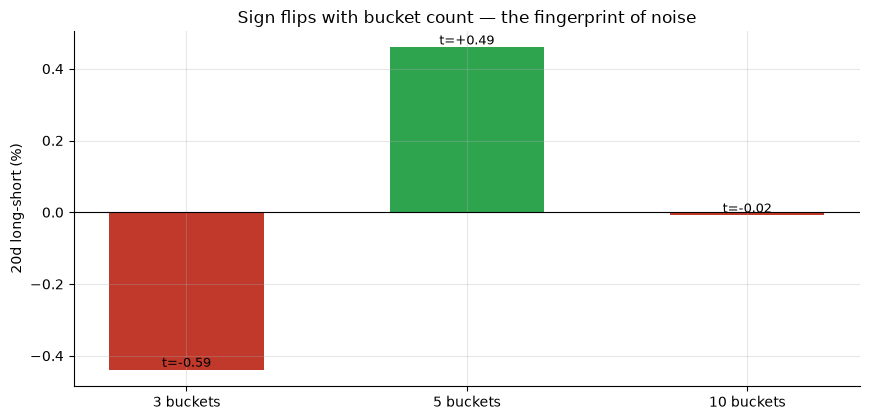

robustness (buckets, ls%, t): [(3, -0.44, -0.59), (5, 0.46, 0.49), (10, -0.01, -0.02)]


In [4]:
if HAVE_REAL:
    rob = []
    for nb in (3,5,10):
        s = st.summarize(PRICES, EV, 20, surprise_col='sur', n_buckets=nb, placebo=False)
        rob.append((nb, s['ls_mean']*100, s['t']))
else:
    rob = [(r[0], r[1], r[2]) for r in R['robust']]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
cols = [GREEN if r[1]>0 else RED for r in rob]
ax.bar([f'{r[0]} buckets' for r in rob], [r[1] for r in rob], color=cols, width=.55)
ax.axhline(0, c='k', lw=.8)
for i,r in enumerate(rob): ax.annotate(f't={r[2]:+.2f}',(i,r[1]),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('20d long-short (%)'); ax.set_title('Sign flips with bucket count — the fingerprint of noise')
plt.tight_layout(); plt.show()
print('robustness (buckets, ls%, t):', [(r[0], round(r[1],2), round(r[2],2)) for r in rob])

> 💡 In plain words: terciles give **-0.44%** (negative), quintiles **+0.46%**, deciles **-0.01%** (~zero). A signal that changes sign when you re-bucket it isn't a signal.

### 4d · The decisive incremental test — does revenue add info beyond EPS?

Jegadeesh-Livnat's actual claim. Match each revenue event to the same name's reported **EPS surprise** (study 363's cache, ±25 days) and run the SUR long-short **within EPS-sign strata**. If revenue carried incremental information, the SUR sort should still pay even after the EPS surprise's sign is held fixed.

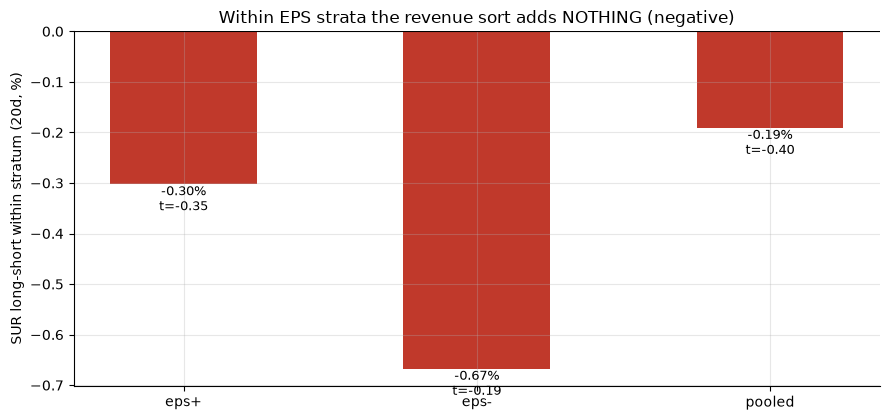

strata: [('eps+', 488, -0.3, -0.35), ('eps-', 72, -0.67, -0.19)]
pooled within-EPS SUR long-short: -0.19% t = -0.4


In [5]:
if HAVE_REAL and os.path.exists('../../363-pead-drift/_cache/pead_events.csv'):
    import pandas as pd
    eps = pd.read_csv('../../363-pead-drift/_cache/pead_events.csv', parse_dates=['date'])
    fr = st.attach_eps(st.event_drift_frame(PRICES, EV, 20), eps)
    inc = st.incremental_to_eps(fr, 'sur')
    strata = [(k, v['n'], v['ls_mean']*100, v['t']) for k,v in inc['strata'].items()]
    pooled = (inc['n_matched'], inc['pooled_ls_mean']*100, inc['pooled_t'])
else:
    strata = [(R['inc'][0][0], R['inc'][0][1], R['inc'][0][2], R['inc'][0][3]),
              (R['inc'][1][0], R['inc'][1][1], R['inc'][1][2], R['inc'][1][3])]
    pooled = R['inc_pooled']
labels = [s[0] for s in strata] + ['pooled']
vals = [s[2] for s in strata] + [pooled[1]]
tvs  = [s[3] for s in strata] + [pooled[2]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(labels, vals, color=[RED if v<=0 else GREEN for v in vals], width=.5)
ax.axhline(0, c='k', lw=.8)
for i,(v,t) in enumerate(zip(vals,tvs)): ax.annotate(f'{v:+.2f}%\nt={t:+.2f}',(i,v),ha='center',va='top',fontsize=9)
ax.set_ylabel('SUR long-short within stratum (20d, %)')
ax.set_title('Within EPS strata the revenue sort adds NOTHING (negative)')
plt.tight_layout(); plt.show()
print('strata:', [(s[0], s[1], round(s[2],2), round(s[3],2)) for s in strata])
print('pooled within-EPS SUR long-short:', f'{pooled[1]:+.2f}%', 't =', round(pooled[2],2))

> 💡 In plain words: inside EPS **beats** the SUR sort is **-0.30%** (t = -0.35); inside EPS **misses**, **-0.67%** (t = -0.19); pooled **-0.19%** at **t = -0.40**. Holding the earnings surprise fixed, the revenue surprise adds **no** drift. This is the Jegadeesh-Livnat headline claim — and it does not replicate here.

### 4e · Costs — academic only, and negative anyway

Gross vs net (4 one-way legs at 10 bps + 50 bps/yr borrow on the short). There's no gross edge to erode; net is zero-or-negative everywhere.

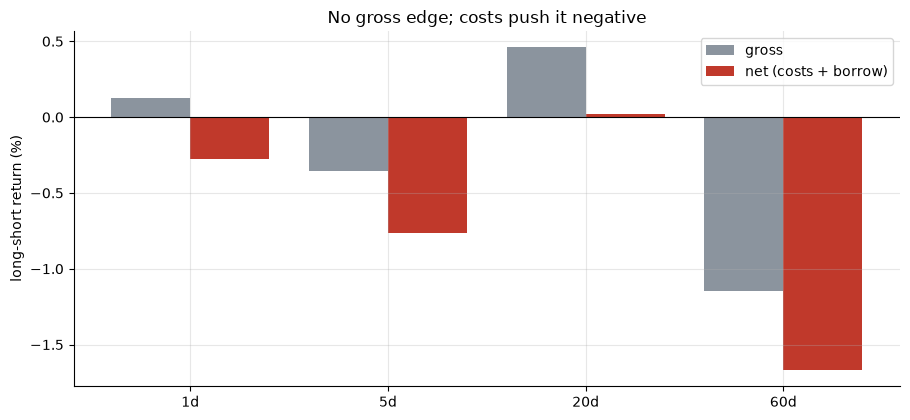

 1d: gross=+0.13%  net=-0.27%
 5d: gross=-0.35%  net=-0.76%
20d: gross=+0.46%  net=+0.02%
60d: gross=-1.15%  net=-1.67%


In [6]:
if HAVE_REAL:
    g, nv = [], []
    for h in hs:
        c = st.net_of_costs(PRICES, EV, h, surprise_col='sur')
        g.append(c['gross']*100); nv.append(c['net']*100)
else:
    g = [n[1] for n in R['net']]; nv = [n[2] for n in R['net']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREY, label='gross')
ax.bar(x+.2, nv, .4, color=RED, label='net (costs + borrow)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('long-short return (%)'); ax.set_title('No gross edge; costs push it negative')
ax.legend(); plt.tight_layout(); plt.show()
for h,gg,nn in zip(hs,g,nv): print(f'{h:>2}d: gross={gg:+.2f}%  net={nn:+.2f}%')

> 💡 In plain words: the best net number is a **+0.02%** crumb at 20 days; everything else is negative. With no gross signal, costs simply finish the job. Nothing to deploy.

### 4f · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a known post-event drift: with **zero** edge the long-short must stay at t≈0 (no false positive); with a **large** planted drift it must light up. Both hold — so the flat real-tape result is a genuine absence of signal, not a broken detector.

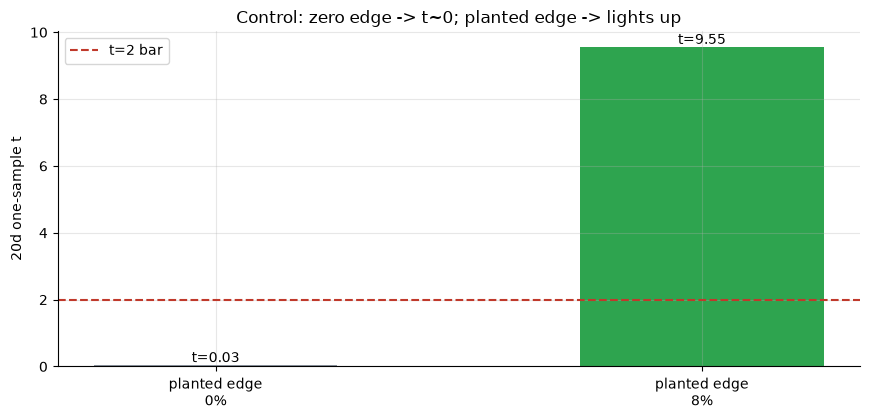

planted +0%: events=1224 ls20=+0.02% t=0.03 p=0.492 win=48%
planted +8%: events=1224 ls20=+5.38% t=9.55 p=0.000 win=67%


In [7]:
res = []
for edge in (0.0, 0.08):
    px, e = data.synthetic_rev(edge=edge, seed=534)
    s = st.summarize(px, e, 20, n_draws=4000)
    res.append((edge, s['n_events'], s['ls_mean']*100, s['t'], s['p_placebo'], s['ls_win']*100))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}%' for e,_,_,_,_,_ in res]
tvals = [r[3] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: zero edge -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,ls,t,p,w in res: print(f'planted {e*100:+.0f}%: events={k} ls20={ls:+.2f}% t={t:.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted drift the control sits at **t = 0.03** (no false positive); a **+8%** planted drift reaches **t = 9.55**. The machinery is unbiased and well-powered — so the real-tape max **t = 0.59** is a true null on this basket, not a measurement failure.

## 5 · The verdict

- **Signal `NONE`** — SUR long-short never clears **t = 2** (max **t = 0.59** at 1d; 20d **+0.46%** at **t = 0.49**, placebo **p = 0.320**, block-placebo **p = 0.582**), the cross-section is non-monotone, and the sign flips with the bucket count. The faithful synthetic control (zero→t = 0.03, planted→t = 9.55) shows the detector works — there is no revenue drift to find here. Literature support is **not** enough. NONE, not WEAK.
- **Tradability `MIRAGE`** — net of 4×10-bps + borrow, every horizon is ≤ **+0.02%** (best, 20d); no gross edge to erode, nothing to deploy.
- **Adds info beyond EPS? `BUSTED`** — within EPS-sign strata the SUR long-short is **-0.19% at t = -0.40** (negative in both beats and misses). The specific Jegadeesh-Livnat incremental claim does not replicate on this conservative large-cap survivor basket.

## 6 · Could you trade it? — the honest contrast with the EPS sibling

The point is not "drift is fake." The **earnings** version (study 363) clears the bar at **t = 2.96** on a near-identical basket and engine. It's the **revenue** twin — and especially its *incremental* claim — that doesn't survive. Same machinery, same kind of names, opposite verdict: the fundamental that drifts is earnings, not sales.

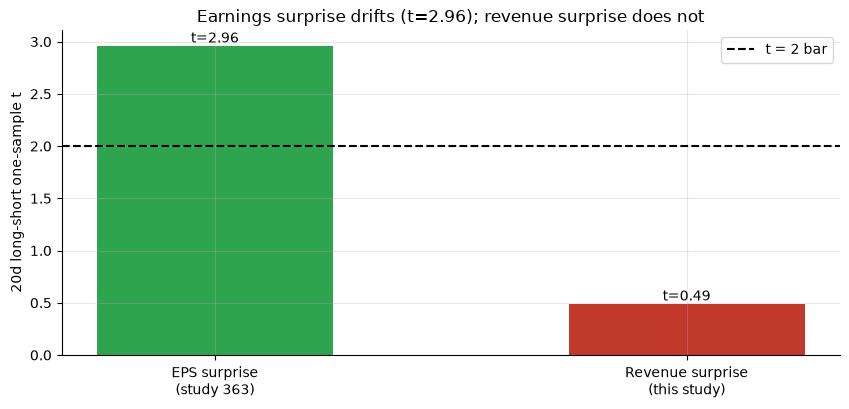

EPS 20d t (363): 2.96 | revenue 20d t (here): 0.49


In [8]:
labels = ['EPS surprise\n(study 363)', 'Revenue surprise\n(this study)']
tvals = [2.96, R['h20'][6]]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(labels, tvals, color=[GREEN, RED], width=.5)
ax.axhline(2, ls='--', c='k', label='t = 2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d long-short one-sample t'); ax.legend()
ax.set_title('Earnings surprise drifts (t=2.96); revenue surprise does not')
plt.tight_layout(); plt.show()
print('EPS 20d t (363):', 2.96, '| revenue 20d t (here):', round(R['h20'][6],2))

> 💡 In plain words: a clean side-by-side. The earnings surprise drifts at **t = 2.96**; the revenue surprise sits at **t = 0.49** and adds nothing incremental. On a tradable large-cap basket in 2013–2026, the revenue-surprise drift is a **mirage** — hence **None × Mirage × Busted**.

## 7 · Going further

- **Liquidity is the knob.** Chordia et al. (2009) put the whole drift family in **small, illiquid** names — exactly what our large-cap basket excludes. A small-cap re-run may revive the revenue drift (with worse costs and survivorship).
- **Post-publication decay.** McLean & Pontiff (2016): Jegadeesh-Livnat is 20 years old; a 2013–2026 null is consistent with documented anomaly decay.
- **The incremental claim is the crux.** A raw SUR drift could just be the EPS drift; the within-EPS-strata test is the honest way to isolate revenue's *own* signal — and it's the test that fails most cleanly here.

*The reproducible core is offline and deterministic; SUR is built from EDGAR frame-tagged quarterly revenue. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*